## Training LSTM Models 
* **Data and Metadata Analysis as well as Dataset preparation: dsPrep.ipynb**
* **Performance evaluation in Test Dataset: results.ipynb**

### In this Notebook: 
- Training pipeline of LSTMs models 
- Evaluation of training process

### Imbalanced Dataset - 8416 entries
 - Non-Death (0): 7189/8416 (84.5%) 
 - Death (1):1227/8416 (15.5%)

### Train Dataset (80%) - 6732 entries
 - Non-Death (0): 5751 (85.4%)
 - Death (1):     981 (14.6%) 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Any

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, auc

import time
import datetime
from tqdm import tqdm
import copy

from pathlib import Path
import glob
import os

BASE_DIR = Path().resolve()

In [ ]:
df_train = pd.read_csv(BASE_DIR / "ds_lstm" / "trainLSTM.csv")
 

In [3]:
#df_train.info()

### Handle with Missing Data
- **Forward Fill (FFILL) Horizontally: Within each patient's timeline (row), missing values are replaced by the last known valid observation.** - **We assume that the most recent state is the best predictor of the current state.**
- **Row Mean Imputation: If the first observation of a timeline is missing (where forward fill cannot reach),** - **It is filled with the arithmetic mean of all available measurements for that specific patient.**

In [ ]:

def impute_missing_values(
    df: pd.DataFrame, 
    feature_prefixes: List[str], 
    time_steps: int = 12
) -> pd.DataFrame:
    """Imputes missing values horizontally in a wide-format clinical dataset.

    Applies a Forward Fill (LOCF) across time columns for each feature, 
    assuming that the most recent state is the best predictor of the 
    current state. If initial observations are missing, they are filled 
    with the arithmetic mean of all available measurements for that patient.

    Args:
        df: The input pandas DataFrame containing the clinical data.
        feature_prefixes: A list of string prefixes for the features 
            to be imputed (e.g., ['GCS', 'Urine', 'Temp']).
        time_steps: The total number of sequential time columns per feature.
            Defaults to 12 (representing t0 to t11).

    Returns:
        A new pandas DataFrame with the imputed values.
    """
    # Create a copy to prevent SettingWithCopy warnings and mutating original data
    df_imputed = df.copy()
    
    for prefix in feature_prefixes:
        # Generate the chronological column names for the current feature
        # Example: ['GCS_t0', 'GCS_t1', ..., 'GCS_t11']
        cols = [f'{prefix}_t{i}' for i in range(time_steps)]
        
        # 1. Forward Fill (FFILL) horizontally
        # Fills missing values with the last known valid observation (axis=1)
        df_imputed[cols] = df_imputed[cols].ffill(axis=1)
        
        # 2. Row Mean Imputation for remaining initial NaNs
        # Calculates the mean of the available measurements for this specific row (patient)
        row_means = df_imputed[cols].mean(axis=1)
        
        # Fills the remaining NaNs using the calculated row means. 
        # Iterating over columns is the safest and most efficient way to map a Series to a DataFrame.
        for col in cols:
            df_imputed[col] = df_imputed[col].fillna(row_means)
            
    return df_imputed



In [5]:
features_to_impute = ['GCS', 'Urine', 'Temp', 'HR', 'DiasABPf', 'MAPf', 'SysABPf']
df_train = impute_missing_values(df_train, feature_prefixes=features_to_impute)

In [6]:
#df_train.info() - 6372 non_nunll


## LSTM
#### Torch architetures

In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau


# Detect CUDA or MPS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Mac (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU NVIDIA (CUDA)")
else:
    device = torch.device("cpu")
    print(" OnlyCPU")

Mac (MPS)


In [9]:

# 1. Targetting separation
X = df_train.drop(['RecordID', 'In-hospital_death'], axis=1)
y = df_train['In-hospital_death'].values

# 2. Normalizaton
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#3. Reshape  (Samples, Time_Steps, Features)
n_samples = X_scaled.shape[0] #n_rows
n_timesteps = 12
n_features = X_scaled.shape[1] // n_timesteps # n medical parameters

X_reshaped = X_scaled.reshape(n_samples, n_timesteps, n_features)

# 4. Tensorising for PyTorch 
X_train = torch.tensor(X_reshaped, dtype=torch.float32) 
y_train = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Formato (N, 1)

#train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64) #  train_loader contain the whole train data separeted in batchs 




---

### Gates Description of the LSTM

Mathematically, suppose that there are $h$ hidden units, the batch size is $n$, and the number of inputs is $d$. Thus, the input is $X_t \in \mathbb{R}^{n \times d}$ and the hidden state of the previous time step is $H_{t-1} \in \mathbb{R}^{n \times h}$. Correspondingly, the gates at time step $t$ are defined as follows: the **input gate** is $I_t$, the **forget gate** is $F_t$, and the **output gate** is $O_t$. 



They are calculated as follows:

$$I_t = \sigma(X_t W_{xi} + H_{t-1} W_{hi} + b_i)$$

$$F_t = \sigma(X_t W_{xf} + H_{t-1} W_{hf} + b_f)$$

$$O_t = \sigma(X_t W_{xo} + H_{t-1} W_{ho} + b_o)$$

Where:
* $W_{xi}, W_{xf}, W_{xo} \in \mathbb{R}^{d \times h}$ and $W_{hi}, W_{hf}, W_{ho} \in \mathbb{R}^{h \times h}$ are **weight parameters**.
* $b_i, b_f, b_o \in \mathbb{R}^{1 \times h}$ are **bias parameters**. 


---



---

### Internal Processing: Input Node, Cell State, and Hidden State

Following the calculation of the gates ($I_t, F_t,$ and $O_t$), the LSTM updates its internal memory through the following components:



#### 1. Input Node (Candidate Cell State) – $\tilde{C}_t$
The **Input Node** represents the "new information" that the network proposes to add to its long-term memory, based on the current input $X_t$ and the previous hidden state $H_{t-1}$.

$$\tilde{C}_t = \tanh(X_t W_{xc} + H_{t-1} W_{hc} + b_c)$$

* **The Role of $\tanh$:** Unlike the gates (which use Sigmoid to act as binary-like switches), the Input Node uses the hyperbolic tangent function to map values into the interval $(-1, 1)$. This allows the network to either "increase" or "decrease" values in the cell state.

#### 2. Memory Cell Internal State (Cell State) – $C_t$
Often described as the "conveyor belt" of the LSTM, the **Cell State** is the long-term memory that flows through the entire sequence with only minor linear interactions.

$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t$$

* **The Mechanism:** $F_t \odot C_{t-1}$: The **Forget Gate** decides what to discard from the previous memory.
    * $I_t \odot \tilde{C}_t$: The **Input Gate** decides how much of the new candidate information should be written into the state.
* **Notation:** The symbol $\odot$ denotes the **Hadamard product** (element-wise multiplication).

#### 3. Hidden State – $H_t$
The **Hidden State** is the "short-term memory" or the output that the network reveals to the external world (or the next layer) at time $t$. It is a filtered version of the Cell State.

$$H_t = O_t \odot \tanh(C_t)$$

* **The Filter:** The Cell State passes through a $\tanh$ function (to stabilize values) and is then scaled by the **Output Gate** $O_t$. This allows the network to maintain a rich internal memory ($C_t$) while only outputting what is relevant for the current prediction ($H_t$).

---

### Summary of Dimensions for Implementation

| Component | Symbol | Dimension in your Model |
| :--- | :--- | :--- |
| **Input Weights** | $W_{xc}$ | $\mathbb{R}^{d \times h}$ (Features $\times$ Hidden Dim) |
| **Input Node** | $\tilde{C}_t$ | $\mathbb{R}^{n \times h}$ (Batch $\times$ Hidden Dim) |
| **Cell State** | $C_t$ | $\mathbb{R}^{n \times h}$ (Batch $\times$ Hidden Dim) |
| **Hidden State** | $H_t$ | $\mathbb{R}^{n \times h}$ (Batch $\times$ Hidden Dim) |

---


![alt text](image.png)

https://d2l.ai/chapter_recurrent-modern/lstm.html

In [ ]:

from blitz.modules import BayesianLSTM, BayesianLinear
from blitz.utils import variational_estimator

@variational_estimator
class LSTMClassifier(nn.Module):
    """Implementation of an LSTM for binary classification (Deterministic or Bayesian).

    This module allows toggling between a standard deterministic LSTM and a 
    Bayesian LSTM using Variational Inference (via the BLITZ library).

    Attributes:
        hidden_dim (int): Number of features in the hidden state.
        layer_dim (int): Number of recurrent layers (stacked LSTMs).
        bayesian (bool): Flag indicating if the network uses Bayesian layers.
        dropout_rate (float): The dropout probability.
        lstm (nn.LSTM): The deterministic LSTM module (if bayesian is False).
        lstm_layers (nn.ModuleList): Stacked Bayesian LSTM layers (if bayesian is True).
        fc (nn.Module): The fully connected linear layer (Deterministic or Bayesian).
        dropout_layer (nn.Dropout): Post-LSTM dropout layer.
        sigmoid (nn.Sigmoid): Sigmoid activation for binary classification.
    """

    def __init__(self, input_dim: int, hidden_dim: int, layer_dim: int, 
                 output_dim: int, dropout: float = 0.2, bayesian: bool = False):
        """Initializes the LSTMClassifier.

        Args:
            input_dim: Number of expected features in the input sequence.
            hidden_dim: Number of features in the hidden state 'h'.
            layer_dim: Number of recurrent layers (stacked LSTMs).
            output_dim: Number of output units (typically 1 for binary classification).
            dropout: Dropout probability in [0, 1]. Defaults to 0.2.
            bayesian: If True, uses Bayesian layers with Variational Inference. 
                Defaults to False.

        Raises:
            ValueError: If the dropout probability is not between 0.0 and 1.0.
        """
        super(LSTMClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.bayesian = bayesian
        
        # --- Dropout validation ---
        if dropout is not None and not (0.0 <= dropout <= 1.0):
            raise ValueError(f"Dropout must be in [0, 1] or None, got {dropout}")
        self.dropout_rate = dropout
        
        # --- Architecture definition ---
        if self.bayesian:
            # BLITZ BayesianLSTM does not support 'num_layers' natively.
            # We stack them manually using nn.ModuleList.
            self.lstm_layers = nn.ModuleList()
            for i in range(layer_dim):
                eff_input_dim = input_dim if i == 0 else hidden_dim
                self.lstm_layers.append(BayesianLSTM(eff_input_dim, hidden_dim))
            
            # Bayesian Fully Connected Layer
            self.fc = BayesianLinear(hidden_dim, output_dim)
        else:
            # Original Deterministic Configuration
            lstm_dropout = dropout if (dropout is not None and layer_dim > 1) else 0.0
            self.lstm = nn.LSTM(
                input_size=input_dim, 
                hidden_size=hidden_dim, 
                num_layers=layer_dim,
                batch_first=True,
                dropout=lstm_dropout
            )
            self.fc = nn.Linear(hidden_dim, output_dim)

        # --- Post-LSTM & Inter-layer Dropout ---
        self.dropout_layer = nn.Dropout(dropout) if dropout is not None else None
        
        # Sigmoid: P(y=1|X)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Defines the forward pass of the model.

        Args:
            x: Input tensor of shape (batch_size, sequence_length, input_dim).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim) containing 
                probabilities bounded between 0 and 1.
        """
        if self.bayesian:
            # Pass through stacked Bayesian layers
            out = x
            for i, lstm_layer in enumerate(self.lstm_layers):
                out, _ = lstm_layer(out)
                # Apply inter-layer dropout for stacked layers (except the last one)
                if self.dropout_layer is not None and i < (self.layer_dim - 1):
                    out = self.dropout_layer(out)
            
            # Many-to-One: extract the hidden state of the last timestep
            last_out = out[:, -1, :]
        else:
            # Deterministic pass (PyTorch handles zero-initialization of h0/c0 internally)
            out, _ = self.lstm(x)
            last_out = out[:, -1, :]

        # Apply post-LSTM dropout before the fully connected layer
        if self.dropout_layer is not None:
            last_out = self.dropout_layer(last_out)

        # Final classification
        return self.sigmoid(self.fc(last_out))

    def __repr__(self) -> str:
        """Returns a string representation of the model."""
        dropout_info = f"{self.dropout_rate}" if self.dropout_rate is not None else "disabled"
        return (f"LSTMClassifier(hidden={self.hidden_dim}, layers={self.layer_dim}, "
                f"dropout={dropout_info}, bayesian={self.bayesian})")

### LSTM training pipeline
-  Repeated Stratified K-Fold Cross Validation (3 x 5)
-  Optimizer: ADAM with adaptative LeaninRate = 0.001
-  Loss Function: Binary Cross Entropy Loss (Standad and Ensemble); 
-  50 Epoch

In [13]:

# We convert to Numpy only for Scikit-Learn to split the indices.
X_np = X_train.cpu().numpy()
y_np = y_train.cpu().numpy()
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
max_epochs = 50

In [ ]:
# implementation of EarlyStopping strategy

# class EarlyStopping:
#     """Early Stopping implementation to halt training when Validation Loss stops improving."""
#     def __init__(self, patience=15, min_delta=0.00001):
#         self.patience = patience
#         self.min_delta = min_delta
#         self.counter = 0
#         self.best_loss = None
#         self.early_stop = False
#         self.best_state = None

#     def __call__(self, val_loss, model):
#         if self.best_loss is None:
#             self.best_loss = val_loss
#             # Save the initial best weights
#             self.best_state = copy.deepcopy(model.state_dict())
#         elif val_loss > self.best_loss - self.min_delta:
#             self.counter += 1
#             if self.counter >= self.patience:
#                 self.early_stop = True
#         else:
#             self.best_loss = val_loss
#             # Update the best weights
#             self.best_state = copy.deepcopy(model.state_dict())
#             self.counter = 0



In [ ]:


def train_and_validate_model(model, train_loader, val_loader, optimizer, scheduler, 
                             criterion, max_epochs, kl_weight, train_size, val_size,
                             val_mc_samples=25, is_bayseian = False):
    """
    Executes the full training and validation loop for a single model over max_epochs.
    
    Args:
        model (nn.Module): The PyTorch model to train (Standard or Bayesian).
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        optimizer (Optimizer): PyTorch optimizer (Adam).
        scheduler (LRScheduler): Learning rate scheduler (eReduceLROnPlateau).
        criterion (Loss): Loss function
        max_epochs (int): Number of epochs to train.
        kl_weight (float): Scaling factor for the KL Divergence penalty.
        train_size (int): Total number of samples in the training set.
        val_size (int): Total number of samples in the validation set.
        val_mc_samples (int): Number of Monte Carlo samples for Bayesian validation.
        
    Returns:
        tuple: (best_model_state, best_val_loss, train_loss_hist, val_loss_hist)
    """
    best_model_state = None
    best_val_loss = float('inf')
    
    train_loss_hist = []
    val_loss_hist = []

    for epoch in range(max_epochs):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            
            # Compute Base BCE Loss
            loss = criterion(preds, y_batch)
            
            # Add KL Divergence Penalty if Bayesian
            if getattr(model, 'bayesian', False):
                kl_loss = model.nn_kl_divergence()
                loss += kl_loss * kl_weight
                
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / train_size
        train_loss_hist.append(epoch_train_loss)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                
                if getattr(model, 'bayesian', False):
                    mc_preds = [model(X_batch) for _ in range(val_mc_samples)]
                    preds = torch.stack(mc_preds).mean(dim=0)
                else:
                    
                    preds = model(X_batch)
                
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        epoch_val_loss = running_val_loss / val_size
        val_loss_hist.append(epoch_val_loss)

        # Update Learning Rate Scheduler
        scheduler.step(epoch_val_loss)
        burn_in_epochs = 35 if is_bayseian else 0
        
        # Only evaluate for "Best Model" if we are past the burn-in phase
        if epoch >= burn_in_epochs:
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                
        if (epoch + 1) % 5 == 0 and is_bayseian:
            
            checkpoint_dir = BASE_DIR /"models2"/ "baysianW"
            os.makedirs(checkpoint_dir, exist_ok=True)
            
            # Note: It is highly recommended to pass a 'fold_num' or 'ens_idx' 
            # into your train_and_validate_model function so files don't overwrite each other.
            # Assuming you pass 'fold' as an argument, it looks like this:
            fold_identifier = getattr(model, 'current_fold', 'unknown_fold') # Fallback if fold is not passed
            
            filename = f"checkpoint_fold_{fold_identifier}_epoch_{epoch + 1}.pth"
            save_path = os.path.join(checkpoint_dir, filename)
            
            torch.save(model.state_dict(), save_path)
            
    return best_model_state, best_val_loss, train_loss_hist, val_loss_hist

In [ ]:

# Helpers for calculate predictions and evalutation metrics

def evaluate_fold_metrics(fold_models: list, val_loader: DataLoader, num_mc_samples: int = 25) -> tuple:
    """
    Evaluates the AUC-ROC and AUC-PR metrics for a given fold.
    
    This function dynamically handles deterministic models, Deep Ensembles, 
    and Bayesian models (using Monte Carlo sampling to estimate the predictive mean).

    Args:
        fold_models (list of nn.Module): A list of trained PyTorch models for the current fold.
        val_loader (DataLoader): The validation data loader.
        num_mc_samples (int): Number of Monte Carlo samples to draw if the model is Bayesian.

    Returns:
        tuple: A tuple containing (auc_roc, auc_pr) as floats.
    """
    y_true_fold = []
    y_pred_fold = []

    # Set all ensemble models to evaluation mode
    for m in fold_models:
        m.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            batch_preds = []
            
            # Collect predictions from all models saved in the fold
            for m in fold_models:
                
                # If Bayesian, perform multiple forward passes (Monte Carlo sampling)
                # to extract the expected value (mean) of the predictions
                if getattr(m, 'bayesian', False):
                    mc_samples = [m(X_batch) for _ in range(num_mc_samples)]
                    preds = torch.stack(mc_samples).mean(dim=0)
                else:
                    # Deterministic forward pass
                    preds = m(X_batch)
                    
                batch_preds.append(preds)
            
            # Average the predictions across the Ensemble 
            # (If ensemble_size == 1, this simply returns the single model's prediction)
            avg_batch_preds = torch.stack(batch_preds).mean(dim=0)
            
            # Store arrays in numpy format for Scikit-Learn
            y_pred_fold.append(avg_batch_preds.cpu().numpy())
            y_true_fold.append(y_batch.cpu().numpy())

    # Concatenate all batches into single arrays
    y_true_fold = np.vstack(y_true_fold)
    y_pred_fold = np.vstack(y_pred_fold)

    # Calculate metrics
    auc_roc = roc_auc_score(y_true_fold, y_pred_fold)
    auc_pr = average_precision_score(y_true_fold, y_pred_fold)

    return auc_roc, auc_pr,y_true_fold, y_pred_fold

In [ ]:
# Code For run K-fold Cross Validation

def run_cv_folds(X_tensor: torch.Tensor, y_tensor: torch.Tensor, cv_splitter, 
                 model_kwargs: dict, batch_size: int = 64, max_epochs: int = 50, 
                 lr: float = 0.001, ensemble_size: int = 1, 
                 device: torch.device = torch.device("cpu"), is_bayseian: bool = False):
    """

    Executes the training and validation process across multiple cross-validation folds.
    
    This function handles Standard LSTMs, Bayesian LSTMs (via VI), and Deep Ensembles.
    It incorporates a dynamic Learning Rate decay mechanism (ReduceLROnPlateau) and 
    displays the estimated time for completion (ETA).

    Args:
        X_tensor (torch.Tensor): The full input data tensor (N, T, F).
        y_tensor (torch.Tensor): The full target labels tensor (N, 1).
        cv_splitter: A scikit-learn cross-validator instance (e.g., RepeatedStratifiedKFold).
        model_kwargs (dict): Dictionary of arguments to initialize the LSTMClassifier.
        batch_size (int): Mini-batch size for DataLoader.
        max_epochs (int): Maximum number of training epochs per fold/model.
        lr (float): Initial learning rate for the Adam optimizer.
        ensemble_size (int): Number of models to train per fold (1 for Standard/Bayesian, >1 for Ensembles).
        device (torch.device): The device to run training on (e.g., 'cpu', 'cuda', 'mps').

    Returns:
        list of dict: A list containing the training history and trained models for each fold.
    
    """
    results = []
    
    X_np = X_tensor.cpu().numpy()
    y_np = y_tensor.cpu().numpy()
    
    total_folds = cv_splitter.get_n_splits(X_np, y_np)
    start_time = time.time()
    
    criterion = nn.BCELoss()

    for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_np, y_np), 1):
        print(f"{'='*40}")
        print(f"Starting Fold {fold}/{total_folds}")
        print(f"{'='*40}")

        # 1. Create Fold DataLoaders
        X_train_fold = X_tensor[train_idx].to(device)
        y_train_fold = y_tensor[train_idx].to(device)
        X_val_fold = X_tensor[val_idx].to(device)
        y_val_fold = y_tensor[val_idx].to(device)

        train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold), batch_size=batch_size, shuffle=False)

        kl_weight = 1.0 / len(train_idx)

        fold_models = []
        fold_best_val_losses = []
        fold_train_hist = np.zeros(max_epochs)
        fold_val_hist = np.zeros(max_epochs)

        # 2. Ensemble Loop
        for ens in range(ensemble_size):
            if ensemble_size > 1:
                print(f"  -> Training Ensemble Member {ens + 1}/{ensemble_size}...")

            # Initialize Model, Optimizer, and Scheduler
            model = LSTMClassifier(**model_kwargs).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

            # ------------------------------------------------------------------
            # 3. Epoch Loop Delegated to Auxiliary Function
            # ------------------------------------------------------------------
            best_model_state, best_val_loss, ens_train_hist, ens_val_hist = train_and_validate_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler,
                criterion=criterion,
                max_epochs=max_epochs,
                kl_weight=kl_weight,
                train_size=len(train_idx),
                val_size=len(val_idx),
                is_bayseian = is_bayseian
            )

            # Load the best weights back into the model before saving it
            model.load_state_dict(best_model_state)
            
            # Store ensemble member results
            fold_models.append(model)
            fold_best_val_losses.append(best_val_loss)
            
            # Accumulate histories to average them out later
            fold_train_hist += np.array(ens_train_hist)
            fold_val_hist += np.array(ens_val_hist)

        #4. Finalize Fold Results & Calculate Metrics (AUC: PR and ROC)
        fold_train_hist /= ensemble_size
        fold_val_hist /= ensemble_size
        
        auc_roc, auc_pr, y_true_fold, y_pred_fold = evaluate_fold_metrics(
            fold_models=fold_models, 
            val_loader=val_loader, 
            num_mc_samples=10
        )
        
        results.append({
            'fold': fold,
            'model': fold_models[0] if ensemble_size == 1 else fold_models,
            'best_val_loss': np.mean(fold_best_val_losses),
            'train_loss_hist': fold_train_hist.tolist(),
            'val_loss_hist': fold_val_hist.tolist(),
            "auc_roc": auc_roc, 
            "auc_pr": auc_pr,
            'y_true': y_true_fold,
            'y_pred': y_pred_fold  
        })

        # 5. Calculate and display ETA
        elapsed_time = time.time() - start_time
        time_per_fold = elapsed_time / fold
        remaining_folds = total_folds - fold
        eta_seconds = time_per_fold * remaining_folds
        
        eta_formatted = str(datetime.timedelta(seconds=int(eta_seconds)))
        elapsed_formatted = str(datetime.timedelta(seconds=int(elapsed_time)))
        
        print(f"Fold {fold} Completed")
        print(f"Avg Best Val Loss: {np.mean(fold_best_val_losses):.4f}")
        print(f"Time Elapsed: {elapsed_formatted} | ETA: {eta_formatted}\n")

    print(f"{'='*40}")
    print("Cross-Validation Complete!")
    print(f"Total Time: {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")
    return results

### **Main loop for training Standard and Ensemble Models**

In [ ]:
import itertools

# Dictionary to store all results
all_architectures_results = {}

# --- 1. Define the Hyperparameter Grid ---
layer_dims = [2]
dropout_rates = [0.2]  # Added to match your loop unpacking
lstm_archs = ['standard', 'Ensemb']

# Create combinations
comb = list(itertools.product(layer_dims, dropout_rates, lstm_archs))
total_comb = len(comb)

print(f"Grid Search: {total_comb} combinations to evaluate\n")

# --- 2. Execute Grid Search ---
for i, (n_layers, dropout_rate, arch) in enumerate(comb, 1):
    
    # Determine flags based on architecture name
    is_bayesian = (arch == 'bayesian')
    is_ensemble = (arch == 'Ensemb')
    ensemble_size = 5 if is_ensemble else 1
    
    print(f"\n{'='*75}")
    print(f" Model {i:02d}/{total_comb} | Layers: {n_layers} | Dropout: {dropout_rate} | Type: {arch.upper()}")
    print(f"{'='*75}")
   
    # Dynamically build the model configuration for this specific combination
    model_params = {
        'input_dim': n_features,  
        'hidden_dim': 128,         
        'layer_dim': n_layers,
        'output_dim': 1,
        'dropout': dropout_rate,
        'bayesian': is_bayesian
    }
    
    # Delegate the heavy lifting to the function we built earlier.
    # It will automatically handle the 15 folds (3x5) and display ETAs.
    fold_histories = run_cv_folds(
        X_tensor=X_train, 
        y_tensor=y_train, 
        cv_splitter=rskf, 
        model_kwargs=model_params, 
        batch_size=64, 
        max_epochs=max_epochs, 
        lr=0.001, 
        ensemble_size=ensemble_size, 
        device=device,
        is_bayseian= is_bayesian
    )
    
    # --- 3. Save Results ---
    config_key = (n_layers, dropout_rate, arch)
    all_architectures_results[config_key] = fold_histories

print(f"\n{'*'*75}")
print(" All configurations evaluated and saved to 'all_architectures_results'")
print(f"{'*'*75}")

### **Main loop for training Bayesian Model (Variational Enconder)**

In [ ]:



layer_dims = [2]
dropout_rates = [0.2]  
lstm_archs = ['bayesian']


comb = list(itertools.product(layer_dims, dropout_rates, lstm_archs))
total_comb = len(comb)

print(f"Grid Search: {total_comb} combinations to evaluate\n")

# --- 2. Execute Grid Search ---
for i, (n_layers, dropout_rate, arch) in enumerate(comb, 1):
    
    # Determine flags based on architecture name
    is_bayesian = (arch == 'bayesian')
    is_ensemble = (arch == 'Ensemb')
    ensemble_size = 5 if is_ensemble else 1
    
    print(f"\n{'='*75}")
    print(f" Model {i:02d}/{total_comb} | Layers: {n_layers} | Dropout: {dropout_rate} | Type: {arch.upper()}")
    print(f"{'='*75}")
   
    # Dynamically build the model configuration for this specific combination
    model_params = {
        'input_dim': n_features,  
        'hidden_dim': 128,         
        'layer_dim': n_layers,
        'output_dim': 1,
        'dropout': dropout_rate,
        'bayesian': is_bayesian
    }
    
    # Delegate the heavy lifting to the function we built earlier.
    # It will automatically handle the 15 folds (3x5) and display ETAs.
    fold_histories = run_cv_folds(
        X_tensor=X_train, 
        y_tensor=y_train, 
        cv_splitter=rskf, 
        model_kwargs=model_params, 
        batch_size=64, 
        max_epochs=100, 
        lr=0.001, 
        ensemble_size=ensemble_size, 
        device=device,
        is_bayseian= is_bayesian
    )
    
    # --- 3. Save Results ---
    config_key = (n_layers, dropout_rate, arch)
    all_architectures_results[config_key] = fold_histories

print(f"\n{'*'*75}")


In [ ]:

# Save Models and metrics of training
import pickle

# Destination directory 
save_dir = BASE_DIR / "models2"

# Create the directory if it does not exist yet
os.makedirs(save_dir, exist_ok=True)

# Parallel dictionary to store only the metrics (ignoring heavy PyTorch objects)
metrics_only_results = {}

print(f"\n save files in: {save_dir} ...")

for config_key, fold_histories in all_architectures_results.items():
    n_layers, dropout_rate, arch = config_key
    
    # Create a user-friendly base name for the files based on the configuration
    config_name = f"{arch}_L{n_layers}_D{dropout_rate}"
    metrics_only_results[config_key] = []

    for fold_data in fold_histories:
        fold_num = fold_data['fold']
        model_obj = fold_data['model']
        
        # 1. Copy only the numerical data/lists (ignoring the 'model' key)
        fold_metrics = {k: v for k, v in fold_data.items() if k != 'model'}
        metrics_only_results[config_key].append(fold_metrics)

        # 2. Save the weights (state_dict) of the model(s)
        if isinstance(model_obj, list): 
            # If it is a Deep Ensemble (saves all 5 members separately)
            for ens_idx, m in enumerate(model_obj, 1):
                model_filename = f"{config_name}_fold{fold_num}_ens{ens_idx}.pth"
                model_path = os.path.join(save_dir, model_filename)
                torch.save(m.state_dict(), model_path)
        else: 
            # If it is Standard or Bayesian (single model)
            model_filename = f"{config_name}_fold{fold_num}.pth"
            model_path = os.path.join(save_dir, model_filename)
            torch.save(model_obj.state_dict(), model_path)


metrics_path = os.path.join(save_dir, "all_metrics_histories.pkl")
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_only_results, f)

print(f"{'='*75}")
print(f"All weights (.pth) and metrics (.pkl) have been saved.")
print(f"{'='*75}")

## **Train Analysis**

In [ ]:
# Plot helpers

def plot_selected_models(
    fold_histories: List[Dict[str, Any]], 
    config_key: Tuple[int, float, str]
) -> None:
    """Plots the best, median, and worst fold performances based on validation loss.

    Handles the 'scale illusion' of Bayesian models by using twin axes to display
    the training loss (ELBO) and validation loss (BCE) on different scales. For
    standard and ensemble architectures, it uses a single standard axis.

    Args:
        fold_histories: A list of dictionaries containing the training history 
            and metrics for each fold.
        config_key: A tuple containing (n_layers, dropout_rate, architecture_type).
    """
    n_layers, dropout_rate, arch_type = config_key
    is_bayesian = (arch_type.lower() == 'bayesian')
    
    # 1. Sort folds by the lowest validation loss (from best to worst)
    sorted_folds = sorted(fold_histories, key=lambda x: x['best_val_loss'])
    
    # 2. Select the Best, Median, and Worst folds
    best_fold = sorted_folds[0]
    worst_fold = sorted_folds[-1]
    median_idx = len(sorted_folds) // 2
    median_fold = sorted_folds[median_idx]
    
    selected_folds = [
        ('Best Fold', best_fold),
        ('Median Fold', median_fold),
        ('Worst Fold', worst_fold)
    ]
    
    # 3. Configure the Figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    title = (f"Performance | Layers: {n_layers} | "
             f"Dropout: {dropout_rate} | Type: {arch_type.upper()}")
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    
    for ax, (label, hist) in zip(axes, selected_folds):
        fold_num = hist['fold']
        best_val = hist['best_val_loss']
        
        # --- Plotting for Bayesian Models (Twin Axes) ---
        if is_bayesian:
            color_train = 'tab:blue'
            color_val = 'tab:orange'
            
            # Primary Axis (Left) for Training (BCE + KL)
            ax.set_xlabel('Epochs')
            ax.set_ylabel('Train Loss (ELBO)', color=color_train)
            ax.plot(hist['train_loss_hist'], color=color_train, label='Train Loss (ELBO)')
            ax.tick_params(axis='y', labelcolor=color_train)
            
            # Secondary Y-Axis (Right) for Validation (BCE Only)
            ax2 = ax.twinx()  
            ax2.set_ylabel('Validation Loss (BCE)', color=color_val)
            ax2.plot(hist['val_loss_hist'], color=color_val, label='Val Loss (BCE)')
            ax2.tick_params(axis='y', labelcolor=color_val)
            
            # Title and grid formatting
            ax.set_title(f"{label} (Fold {fold_num})\nBest Val: {best_val:.4f}")
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # Combine legends from both axes into a single box
            lines_1, labels_1 = ax.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

        # --- Plotting for Standard/Ensemble Models (Single Axis) ---
        else:
            ax.plot(hist['train_loss_hist'], label='Train Loss', color='blue')
            ax.plot(hist['val_loss_hist'], label='Validation Loss', color='orange')
            
            ax.set_title(f"{label} (Fold {fold_num})\nBest Val: {best_val:.4f}")
            ax.set_xlabel('Epochs')
            ax.set_ylabel('BCE Loss')
            ax.legend(loc='upper right')
            ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()



### **Analysis of loss funcion (Train and Validarion group)**

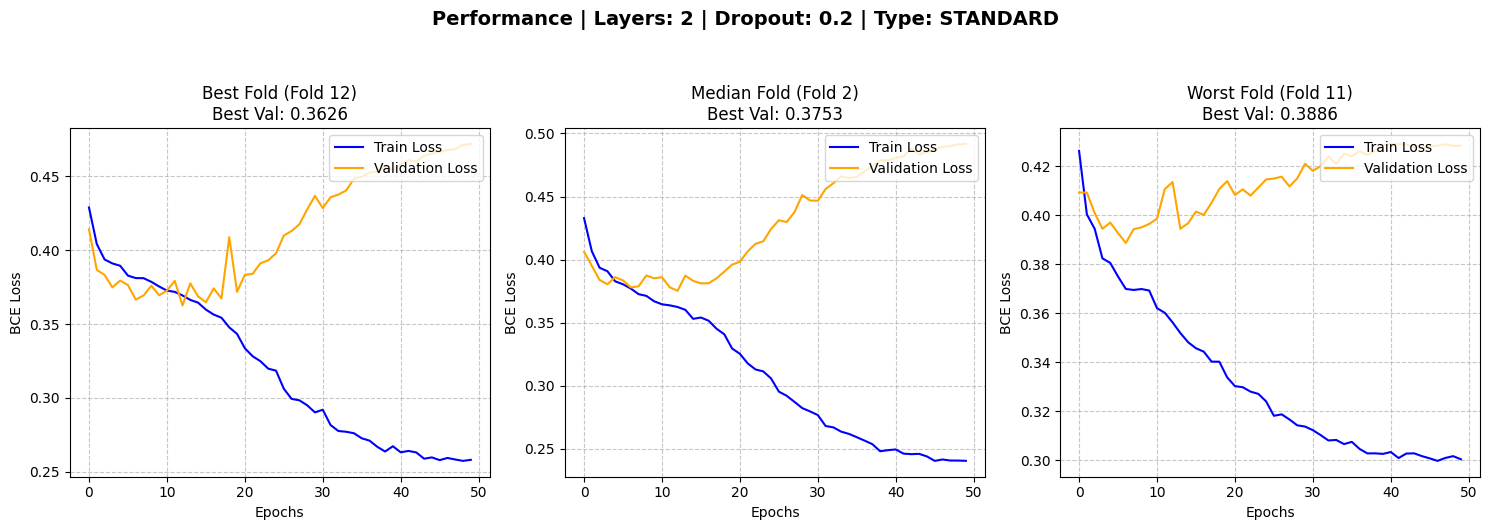

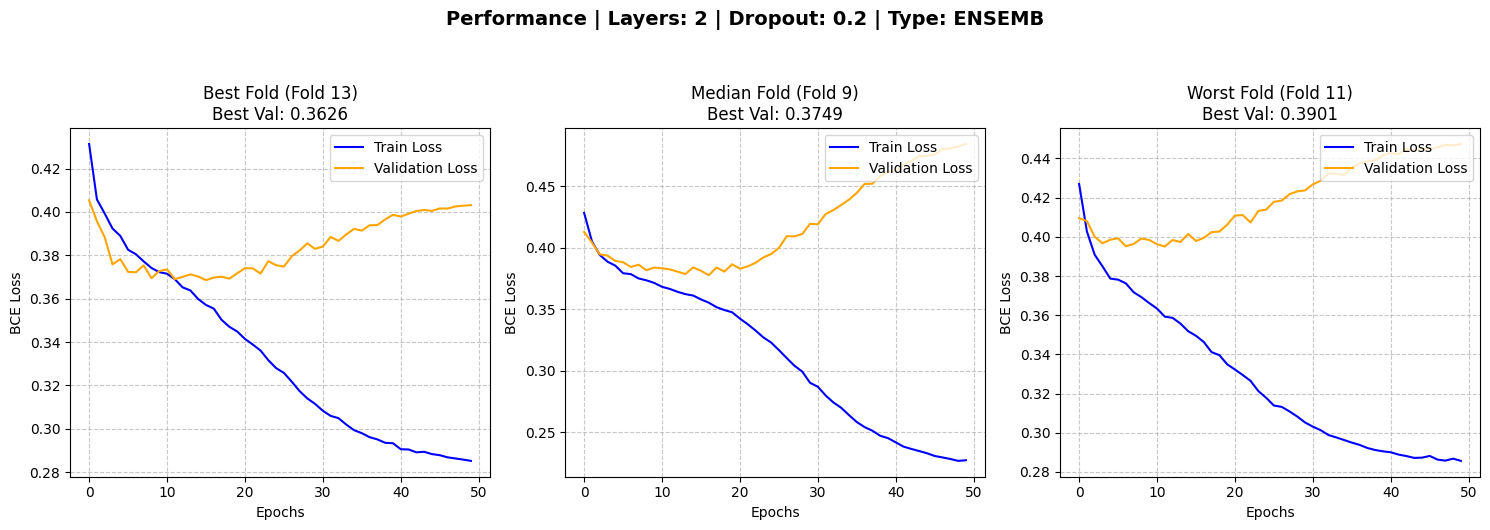

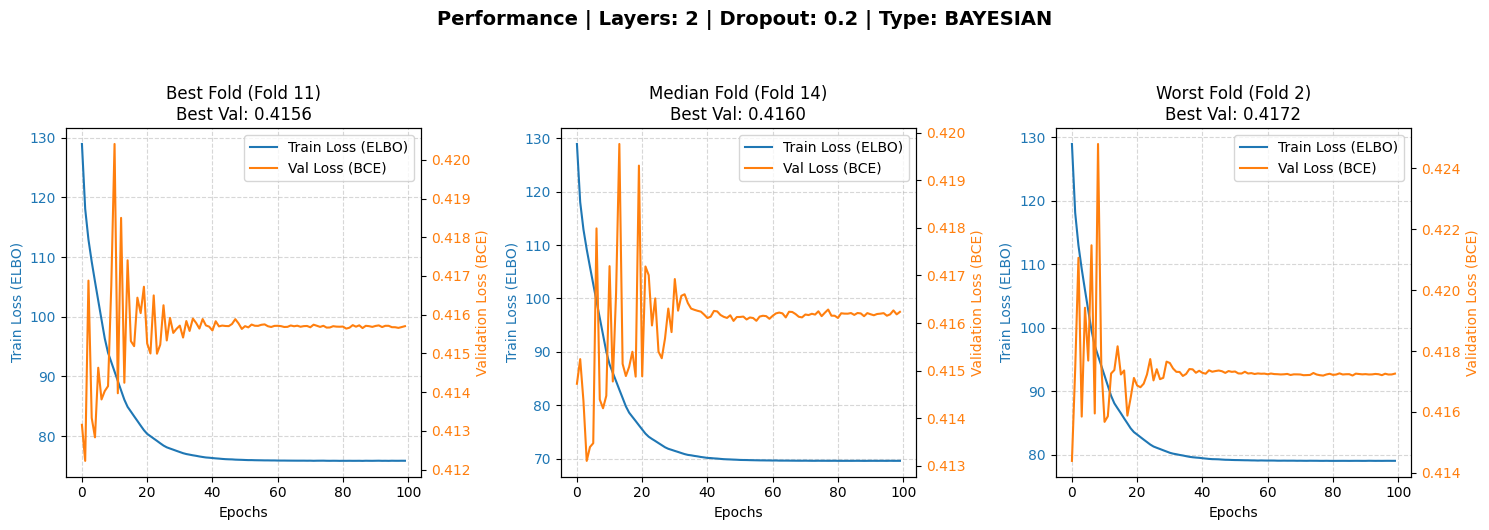

In [22]:
for config_key, fold_histories in all_architectures_results.items():
    plot_selected_models(fold_histories, config_key=config_key)

In [ ]:

#plot helpers


def plot_roc_pr_curves(
    fold_histories: List[Dict[str, Any]], 
    config_key: Tuple[int, float, str]
) -> None:
    """Plots the ROC and Precision-Recall curves for the best, median, and worst folds.

    Combines the curves into two side-by-side subplots to easily compare 
    model stability across cross-validation folds.

    Args:
        fold_histories: A list of dictionaries containing the training history, 
            metrics, and raw predictions ('y_true', 'y_pred') for each fold.
        config_key: A tuple containing (n_layers, dropout_rate, architecture_type).
    """
    n_layers, dropout_rate, arch_type = config_key
    
    # 1. Sort folds by the lowest validation loss (consistency with previous plot)
    sorted_folds = sorted(fold_histories, key=lambda x: x['best_val_loss'])
    
    # 2. Select the Best, Median, and Worst folds
    best_fold = sorted_folds[0]
    worst_fold = sorted_folds[-1]
    median_idx = len(sorted_folds) // 2
    median_fold = sorted_folds[median_idx]
    
    # Tuple format: (Label, Fold Data, Line Color)
    selected_folds = [
        ('Best Fold', best_fold, 'tab:green'),
        ('Median Fold', median_fold, 'tab:blue'),
        ('Worst Fold', worst_fold, 'tab:red')
    ]
    
    # 3. Configure the Figure (1 Row, 2 Columns)
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
    
    title = (f"ROC & PR Curves | Layers: {n_layers} | "
             f"Dropout: {dropout_rate} | Type: {arch_type.upper()}")
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    
    for label, hist, color in selected_folds:
        y_true = hist.get('y_true')
        y_pred = hist.get('y_pred')
        fold_num = hist['fold']
        
        if y_true is None or y_pred is None:
            raise ValueError("Keys 'y_true' and 'y_pred' must exist in fold_histories.")
            
        # ==========================================
        # Plot 1: Receiver Operating Characteristic (ROC)
        # ==========================================
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        # Fallback to calculating AUC if 'auc_roc' key is missing
        roc_auc = hist.get('auc_roc', auc(fpr, tpr)) 
        
        ax_roc.plot(fpr, tpr, color=color, lw=2, 
                    label=f"{label} (Fold {fold_num}) | AUC = {roc_auc:.3f}")
        
        # ==========================================
        # Plot 2: Precision-Recall (PR)
        # ==========================================
        precision, recall, _ = precision_recall_curve(y_true, y_pred)
        pr_auc = hist.get('auc_pr', auc(recall, precision))
        
        ax_pr.plot(recall, precision, color=color, lw=2, 
                   label=f"{label} (Fold {fold_num}) | AUC = {pr_auc:.3f}")

    # --- Formatting ROC Plot ---
    
    ax_roc.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Random guess line
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
    ax_roc.set_ylabel('True Positive Rate (Sensitivity)')
    ax_roc.set_title('ROC Curve')
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, linestyle='--', alpha=0.5)

    # --- Formatting PR Plot ---
    
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_xlabel('Recall (Sensitivity)')
    ax_pr.set_ylabel('Precision (Positive Predictive Value)')
    ax_pr.set_title('Precision-Recall Curve')
    ax_pr.legend(loc="lower left")
    ax_pr.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()



### PR and ROC curve 
- Best , Median and Worst Models performance

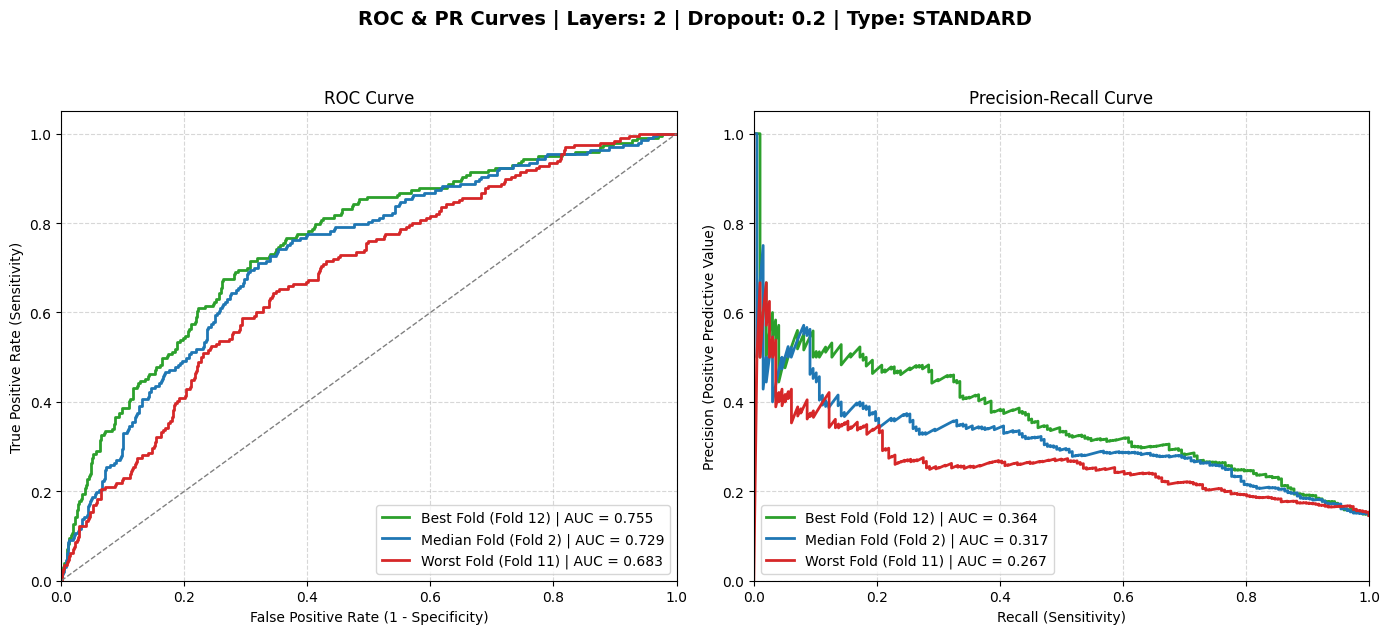

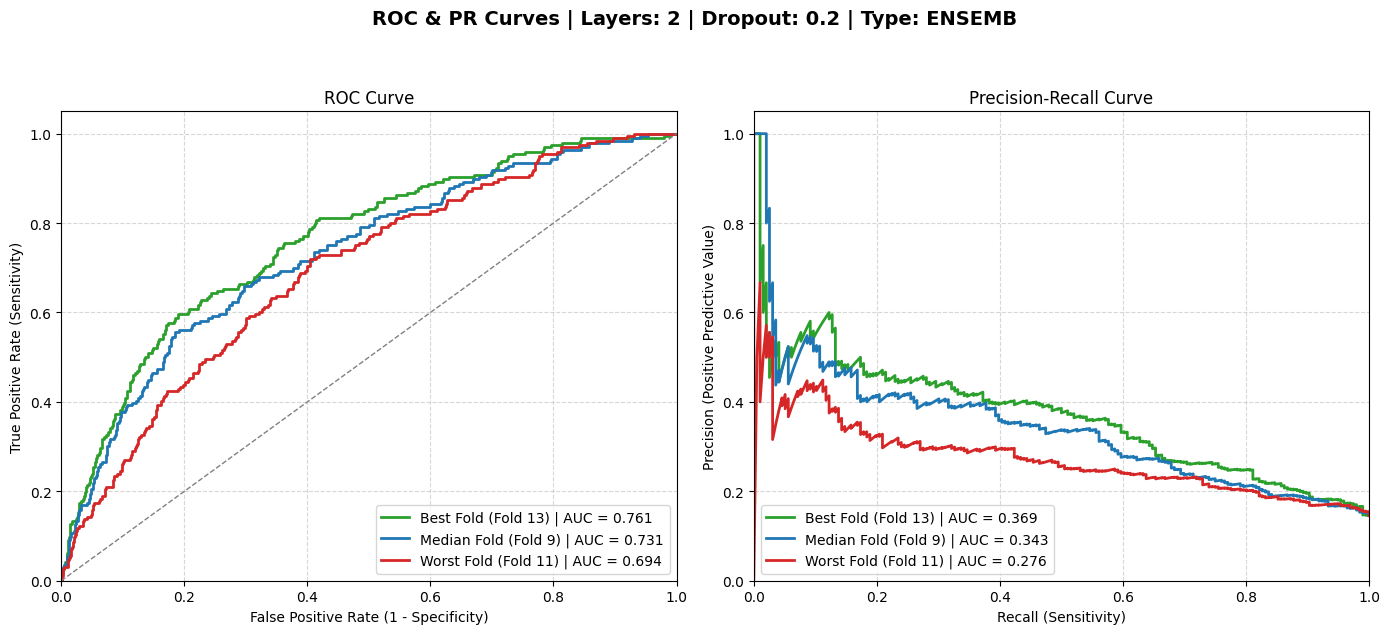

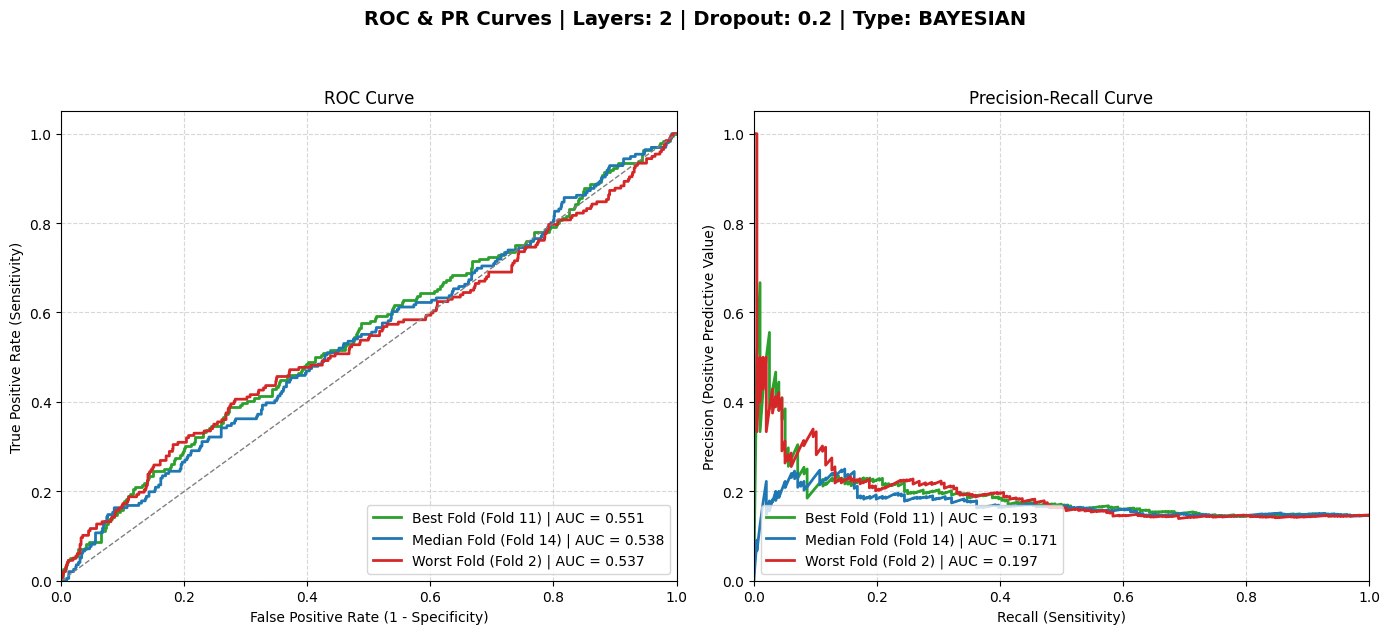

In [24]:

for config_key, fold_histories in all_architectures_results.items():
    plot_roc_pr_curves(fold_histories, config_key=config_key)